# 01 - Data Quality and Exploratory Analysis

Canonical schema validation, duplicate policy, rare-event prevalence and temporal profiles.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
ART = ROOT / 'artifacts'
FIG = ROOT / 'reports' / 'figures'
pd.set_option('display.max_columns', 100)


In [2]:
audit = json.loads((ART / 'data_audit.json').read_text())
pd.Series(audit, name='value')

Out[0]: 
raw_rows                                                               284807
modeling_rows                                                          283726
columns                                                                    31
frauds_raw                                                                492
frauds_modeling                                                           473
fraud_rate_modeling                                                  0.001667
exact_duplicates_removed                                                 1081
missing_values                                                              0
time_min_seconds                                                          0.0
time_max_seconds                                                     172792.0
source_sha256               fdaf12730dc1fc426f318b71349f24f5c5fd00aa115294...
Name: value, dtype: object


In [3]:
splits = pd.read_csv(ART / 'temporal_split_summary.csv')
splits

Out[0]: 
     partition    rows  frauds  fraud_rate  start_hour   end_hour
0        train  156049     332    0.002128    0.000000  30.160000
1   validation   28372      18    0.000634   30.161111  35.142222
2  calibration   28374      30    0.001057   35.142500  38.693889
3       policy   28374      41    0.001445   38.694167  42.033333
4         test   42557      52    0.001222   42.033611  47.997778


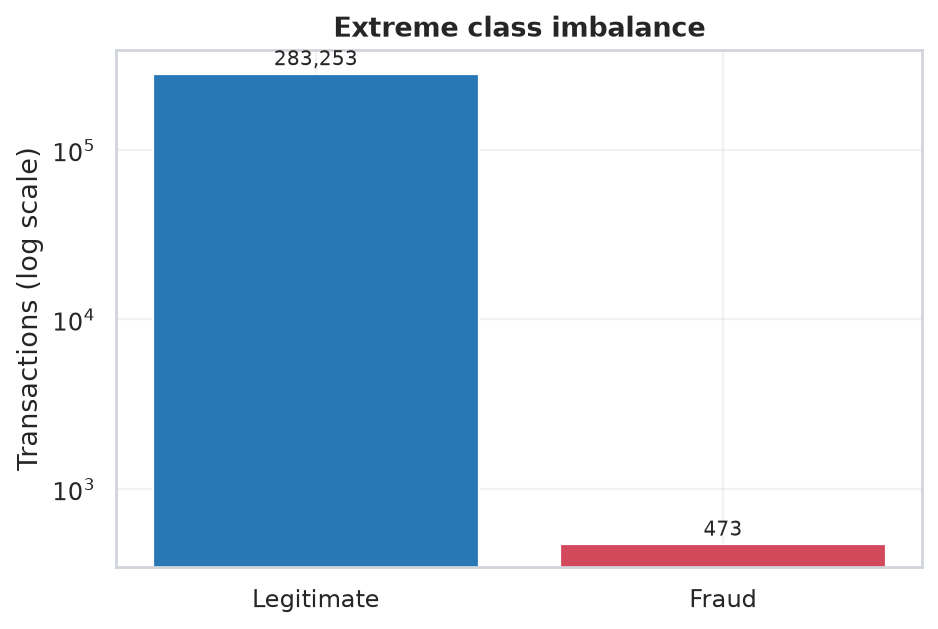

In [4]:
display(Image(filename=str(FIG / '01_class_imbalance.png')))

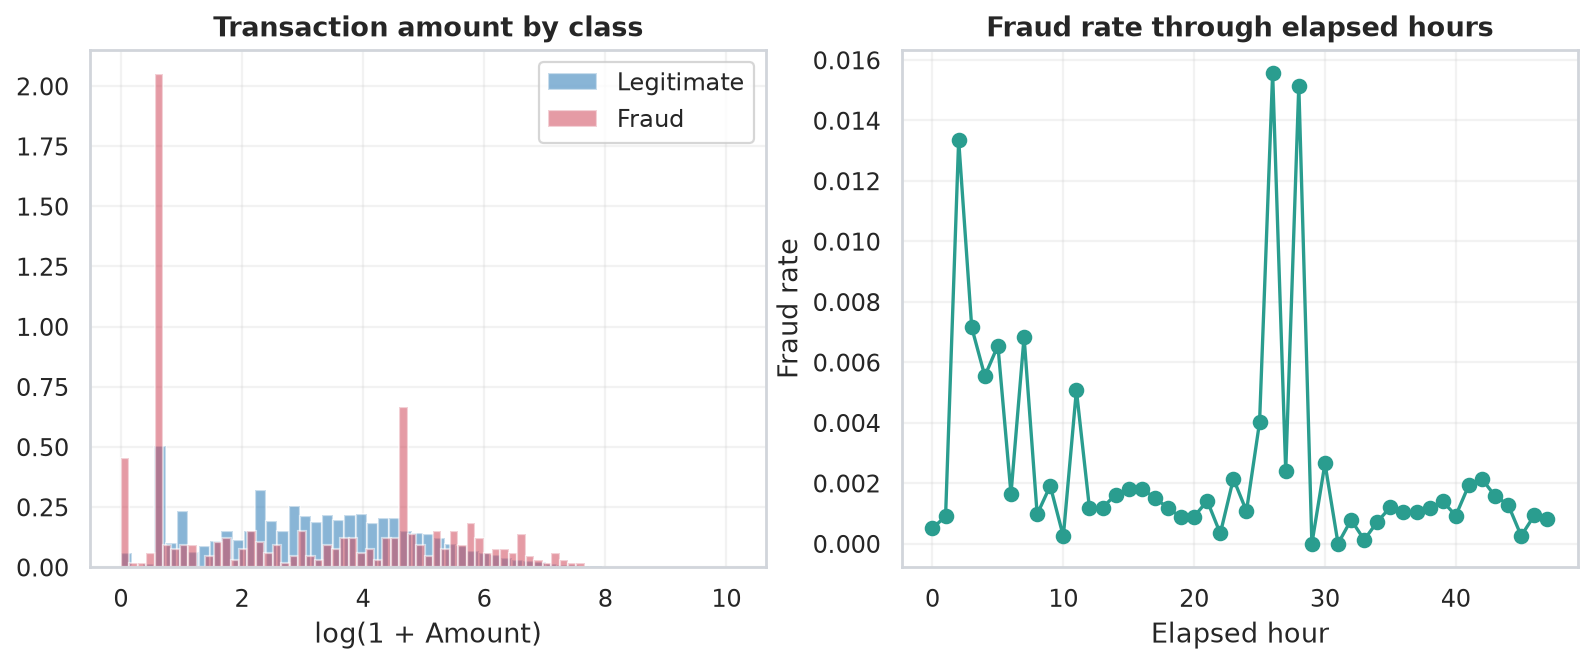

In [5]:
display(Image(filename=str(FIG / '02_amount_and_time.png')))

The raw data contain an extreme rare event. Exact duplicate rows are removed before every temporal boundary; the final holdout remains chronologically later than model, calibration and policy blocks.